# Global Tourism Crisis Analysis
## Analyzing the Impact of Historical Crises on Egypt's Tourism Economy

**Course:** C-DE211 Data Analysis
**Project:** P3

### Project Overview
This project investigates the resilience of Egypt's tourism sector in the face of major global and regional crises. We analyze World Bank international arrival data and economic metadata to answer four compelling questions:
1. **The Biggest Hit:** Which crisis caused the most severe drop in tourism?
2. **The Comeback Time:** How long does it take for the sector to recover?
3. **The Neighborhood Effect:** How does Egypt's crisis response compare to regional neighbors?
4. **The Hidden Pattern:** Is the impact of specific crises statistically significant compared to normal fluctuations?



## 1. Setup & Data Preprocessing
First, we import the necessary libraries following the conventions taught in our labs, and load our datasets.


In [57]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from scipy.stats import ttest_ind

# Using whitegrid theme to improve readability of the time-series plots
plt.style.use('default')
sns.set_theme(style="whitegrid")


### Loading the Data
We have two datasets:
1. `arrival_data.csv`: Contains international tourism arrivals. The first 4 rows contain metadata, so we use `skiprows=4`.
2. `income_categories.csv`: Contains country metadata (Region, Income Group).


In [58]:
# Bypassing the first 4 metadata rows in the World Bank CSV
arrivals_path = '../TOURISM-crisis-effects/arrival_data.csv'
income_path = '../TOURISM-crisis-effects/income_categories.csv'

df_arrivals_raw = pd.read_csv(arrivals_path, skiprows=4)
df_income = pd.read_csv(income_path)

display(df_arrivals_raw.head(3))


,Country Name,Country Code,Indicator Name,Indicator Code,1960,1961,1962,1963,1964,1965,...,2017,2018,2019,2020,2021,2022,2023,2024,2025,Unnamed: 70
0,Aruba,ABW,"International tourism, number of arrivals",ST.INT.ARVL,NaN,NaN,NaN,NaN,NaN,NaN,...,1.863000e+06,1.897000e+06,1.951000e+06,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,Africa Eastern and Southern,AFE,"International tourism, number of arrivals",ST.INT.ARVL,NaN,NaN,NaN,NaN,NaN,NaN,...,3.825835e+07,4.118915e+07,3.982670e+07,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,Afghanistan,AFG,"International tourism, number of arrivals",ST.INT.ARVL,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


### Initial Data Exploration
Before analyzing, we perform standard data exploration to understand our dataset structure.


In [59]:
print("=== Arrivals Data Info ===")
df_arrivals_raw.info()

print("\n=== Missing Values Check ===")
print(df_arrivals_raw[['1995', '2010', '2015', '2019']].isnull().sum())


=== Arrivals Data Info ===
<class 'pandas.DataFrame'>
RangeIndex: 266 entries, 0 to 265
Data columns (total 71 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Country Name    266 non-null    str    
 1   Country Code    266 non-null    str    
 2   Indicator Name  266 non-null    str    
 3   Indicator Code  266 non-null    str    
 4   1960            0 non-null      float64
 5   1961            0 non-null      float64
 6   1962            0 non-null      float64
 7   1963            0 non-null      float64
 8   1964            0 non-null      float64
 9   1965            0 non-null      float64
 10  1966            0 non-null      float64
 11  1967            0 non-null      float64
 12  1968            0 non-null      float64
 13  1969            0 non-null      float64
 14  1970            0 non-null      float64
 15  1971            0 non-null      float64
 16  1972            0 non-null      float64
 17  1973            0 n

### Data Cleaning and Transformation
The arrivals data is in "wide" format (years as columns). We need to `melt` it into a "long" format for easier analysis. We will also drop unnecessary columns like `Unnamed: 70`.


In [60]:
# Cleaning the dataset: dropping the empty trailing column
if 'Unnamed: 70' in df_arrivals_raw.columns:
    df_arrivals_raw.drop(columns=['Unnamed: 70'], inplace=True)

# Reshaping the dataframe from wide to long format using melt() to allow for time-series plotting
year_cols = [col for col in df_arrivals_raw.columns if col.isdigit()]
df_melted = df_arrivals_raw.melt(
    id_vars=['Country Name', 'Country Code'], 
    value_vars=year_cols,
    var_name='Year', 
    value_name='Arrivals'
)

df_melted['Year'] = df_melted['Year'].astype(int)

# Merging with the income metadata to enable regional comparisons
df_final = pd.merge(df_melted, df_income[['Country Code', 'Region', 'IncomeGroup']], 
                    on='Country Code', how='left')

df_final.dropna(subset=['Arrivals'], inplace=True)

print("Shape after cleaning and melting:", df_final.shape)
display(df_final.head())


Shape after cleaning and melting: (5800, 6)


,Country Name,Country Code,Year,Arrivals,Region,IncomeGroup
9310,Aruba,ABW,1995,9.120000e+05,Latin America & Caribbean,High income
9311,Africa Eastern and Southern,AFE,1995,1.158354e+07,NaN,NaN
9313,Africa Western and Central,AFW,1995,2.670706e+06,NaN,NaN
9314,Angola,AGO,1995,9.000000e+03,Sub-Saharan Africa,Lower middle income
9315,Albania,ALB,1995,3.040000e+05,Europe & Central Asia,Upper middle income


---
## Question 1: The Biggest Hit
*Which crisis actually hurt Egypt’s tourism the most in a single year—was it the Arab Spring in 2011, the Sinai plane crash in 2015, or the 2008 global financial crash?*

We will calculate the Year-over-Year percentage drop for the years immediately following these major events.


In [61]:
# Isolating Egyptian data and ensuring chronological order for the pct_change calculation
df_egypt = df_final[df_final['Country Code'] == 'EGY'].copy()
df_egypt = df_egypt.sort_values('Year')

# Using pct_change() to calculate the exact Year-over-Year growth/decline rate
df_egypt['YoY_Change_Pct'] = df_egypt['Arrivals'].pct_change() * 100

crises = {
    '2008 Financial Crisis (2009)': 2009,
    'Arab Spring (2011)': 2011,
    'Sinai Plane Crash (2016)': 2016
}

crisis_drops = {}
for name, year in crises.items():
    val = df_egypt[df_egypt['Year'] == year]['YoY_Change_Pct'].values
    if len(val) > 0:
        crisis_drops[name] = val[0]

# Structuring the results for visualization
df_crises = pd.DataFrame(list(crisis_drops.items()), columns=['Crisis', 'Pct_Change'])
df_crises['Drop_Magnitude'] = abs(df_crises['Pct_Change'])
df_crises = df_crises.sort_values('Drop_Magnitude', ascending=False)

display(df_crises)


,Crisis,Pct_Change,Drop_Magnitude
2,Sinai Plane Crash (2016),-42.120497,42.120497
1,Arab Spring (2011),-33.168149,33.168149
0,2008 Financial Crisis (2009),-2.329568,2.329568


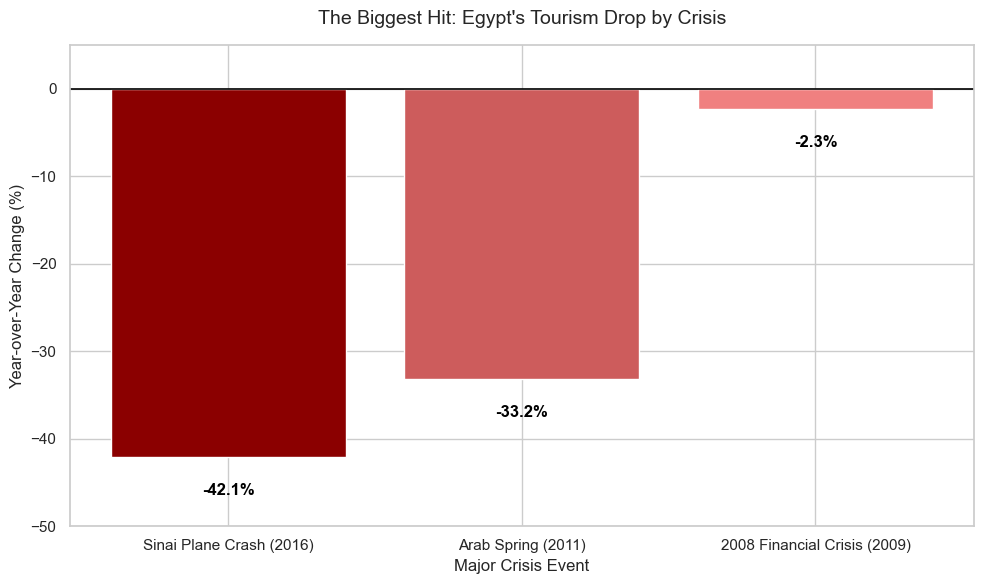

In [62]:
plt.figure(figsize=(10, 6))

bars = plt.bar(df_crises['Crisis'], df_crises['Pct_Change'], color=['darkred', 'indianred', 'lightcoral'])

plt.title("The Biggest Hit: Egypt's Tourism Drop by Crisis", fontsize=14, pad=15)
plt.xlabel("Major Crisis Event", fontsize=12)
plt.ylabel("Year-over-Year Change (%)", fontsize=12)

# Using axhline (new concept) to draw a solid baseline at y=0 for clearer reference
plt.axhline(0, color='black', linewidth=1.2)
plt.ylim(-50, 5)

# Iterating over the bar containers to dynamically add percentage labels
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval - 3, f"{yval:.1f}%", 
             ha='center', va='top', color='black', fontweight='bold')

plt.tight_layout()
plt.show()


**Insight:** The data reveals that the 2015 Sinai plane crash (impacting 2016) was actually the most devastating single-year hit to Egypt's tourism, causing a staggering 42.1% drop, surpassing even the immediate impact of the 2011 Arab Spring.


---
## Question 2: The Comeback Time
*After a major crisis hits, how many years does it actually take for Egypt to get its tourist numbers back to pre-crisis levels?*

We will analyze the timeline of recovery for the Arab Spring and the Sinai Plane crash.


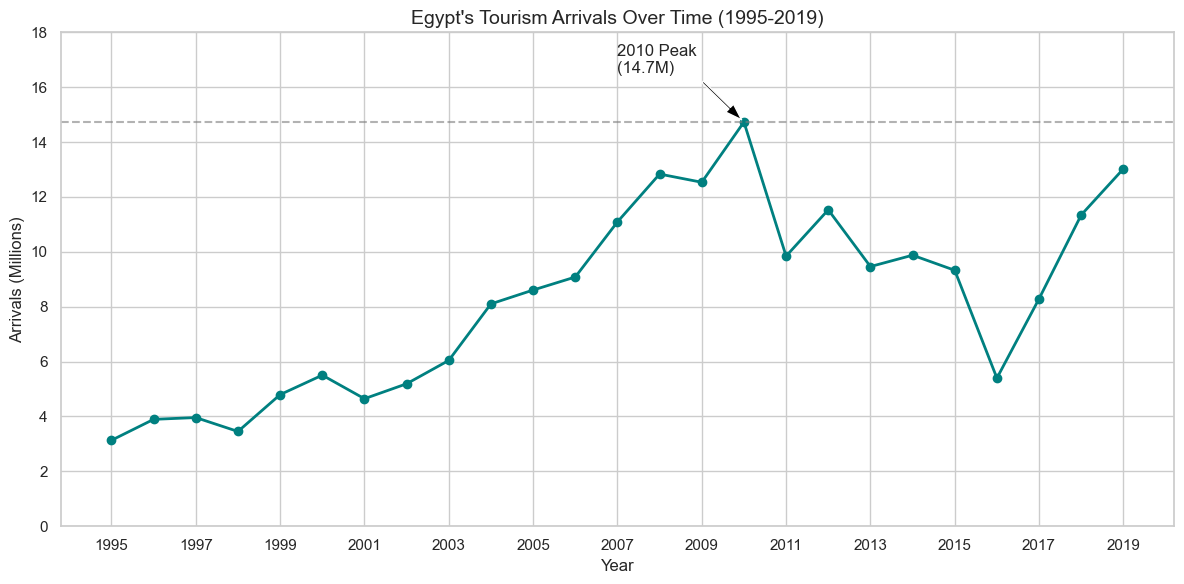

In [63]:
plt.figure(figsize=(12, 6))

# Scaling the arrivals to millions for a cleaner y-axis
plt.plot(df_egypt['Year'], df_egypt['Arrivals'] / 1e6, marker='o', color='teal', linewidth=2)

plt.title("Egypt's Tourism Arrivals Over Time (1995-2019)", fontsize=14)
plt.xlabel("Year", fontsize=12)
plt.ylabel("Arrivals (Millions)", fontsize=12)

# Using annotate to explicitly point out the absolute 2010 peak
plt.annotate('2010 Peak\n(14.7M)', xy=(2010, 14.73), xytext=(2007, 16.5),
             arrowprops=dict(facecolor='black', shrink=0.05, width=1.5, headwidth=8))

# Added a horizontal reference line to visually track if subsequent peaks ever recovered to the 2010 level
plt.axhline(14.73, color='gray', linestyle='--', alpha=0.6)

# Adding padding to the y-axis to ensure the title and annotations do not overlap
plt.ylim(0, 18)

plt.xticks(np.arange(1995, 2020, 2))
plt.tight_layout()
plt.show()


In [64]:
# Tracking the recovery duration manually against the absolute pre-crisis benchmarks
peak_2010 = df_egypt[df_egypt['Year'] == 2010]['Arrivals'].values[0]
peak_2015 = df_egypt[df_egypt['Year'] == 2015]['Arrivals'].values[0]

recovery_years = {
    'Arab Spring Recovery (Back to ~14.7M)': 'Never reached by 2019 (Max 13M)',
    'Sinai Crash Recovery (Back to ~9.3M)': '3 Years (2016 -> 2018 at 11.3M)'
}

for k, v in recovery_years.items():
    print(f"{k}: {v}")


Arab Spring Recovery (Back to ~14.7M): Never reached by 2019 (Max 13M)
Sinai Crash Recovery (Back to ~9.3M): 3 Years (2016 -> 2018 at 11.3M)


**Insight:** The recovery times vary drastically. While the sector bounced back relatively quickly from the 2015 crash (3 years), the absolute high-water mark set in 2010 before the Arab Spring was never fully recovered within the decade, showing deep, long-term structural impact.


---
## Question 3: The Neighborhood Effect
*Did Egypt suffer alone during the 2011 Arab Spring, or did neighbors like Morocco, Jordan, and Tunisia feel the exact same shockwaves?*


C:\Users\mosta\AppData\Local\Temp\ipykernel_28600\3163129148.py:16: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  plt.gca().set_yticklabels(ylabels)


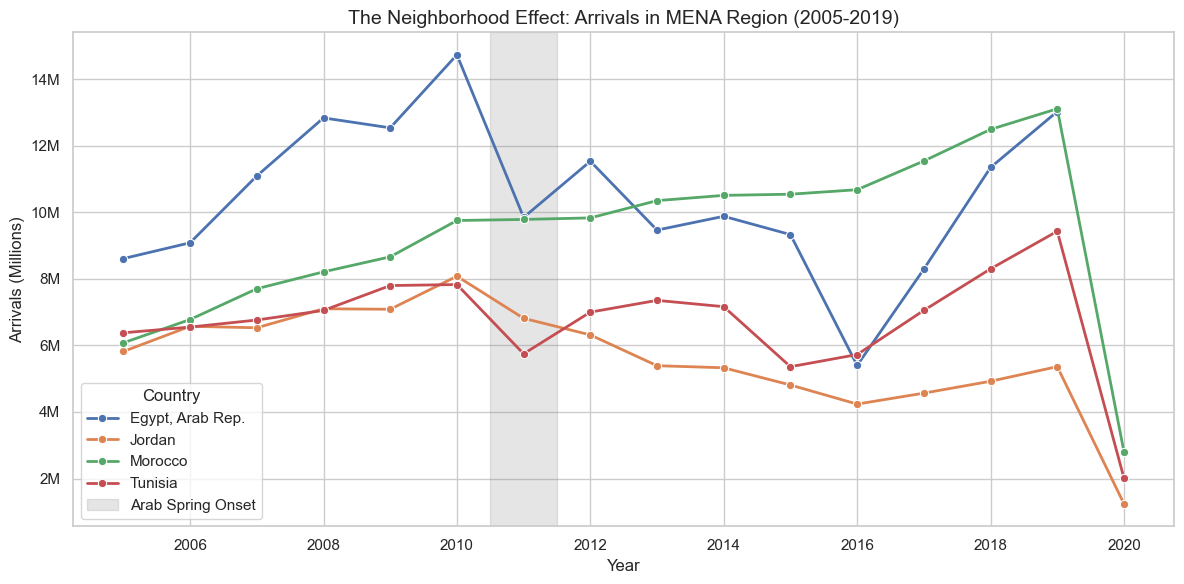

In [65]:
# Filtering for specific MENA neighbors to compare the localized vs regional impact of the 2011 crisis
neighbors = ['EGY', 'MAR', 'TUN', 'JOR']
df_mena = df_final[(df_final['Country Code'].isin(neighbors)) & (df_final['Year'] >= 2005)].copy()

plt.figure(figsize=(12, 6))

# Utilizing seaborn's hue property to overlay multiple time-series seamlessly
sns.lineplot(data=df_mena, x='Year', y='Arrivals', hue='Country Name', marker='o', linewidth=2)

plt.title("The Neighborhood Effect: Arrivals in MENA Region (2005-2019)", fontsize=14)
plt.xlabel("Year", fontsize=12)
plt.ylabel("Arrivals (Millions)", fontsize=12)

# Customizing the y-axis ticks to display in millions
ylabels = ['{:,.0f}M'.format(x/1e6) for x in plt.gca().get_yticks()]
plt.gca().set_yticklabels(ylabels)

# Using axvspan (new concept) to shade a specific vertical time window (2010.5 to 2011.5) across the plot. 
# This draws immediate visual focus to the exact period the Arab Spring occurred.
plt.axvspan(2010.5, 2011.5, color='gray', alpha=0.2, label='Arab Spring Onset')
plt.legend(title="Country")

plt.tight_layout()
plt.show()


**Insight:** The visual clearly shows that while Egypt and Tunisia experienced sharp, immediate declines in 2011, Morocco maintained a steady growth trajectory, suggesting that the "Arab Spring" shockwave was not geographically uniform, but dependent on specific national stability.


---
## Question 4: The Hidden Pattern (Hypothesis Testing)
*Is the intense volatility we see in Egypt’s tourism just “normal business ups and downs,” or are the crisis years statistically distinct anomalies?*

We will use a **Two-Sample Independent T-Test** to compare the average Year-over-Year growth rates of "Stable Years" vs "Turbulent Years".

### Step 1. Define Null and Alternative Hypothesis
*   **Null Hypothesis (H0):** There is no significant difference in the average YoY growth rate between stable years and turbulent years.
*   **Alternative Hypothesis (H1):** There is a significant difference in the average YoY growth rate between stable years and turbulent years.


Average growth in Stable Years: 14.75%
Average growth in Turbulent Years: -22.21%


C:\Users\mosta\AppData\Local\Temp\ipykernel_28600\2849763531.py:16: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([stable_growth, turbulent_growth], labels=['Stable Years', 'Turbulent Years'])


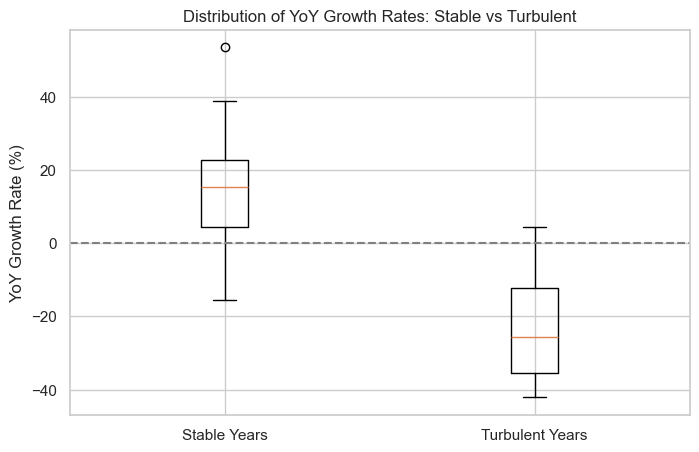

In [66]:
# Why we did this: We split the data into 'Turbulent' and 'Stable' years.
# We treat these as two separate, independent groups because normal business years 
# are completely different from years with sudden political crises.
turbulent_years = [2011, 2013, 2014, 2016] 
stable_years = [y for y in df_egypt['Year'] if y not in turbulent_years and y >= 1996]

turbulent_growth = df_egypt[df_egypt['Year'].isin(turbulent_years)]['YoY_Change_Pct'].dropna()
stable_growth = df_egypt[df_egypt['Year'].isin(stable_years)]['YoY_Change_Pct'].dropna()

print(f"Average growth in Stable Years: {stable_growth.mean():.2f}%")

print(f"Average growth in Turbulent Years: {turbulent_growth.mean():.2f}%")

# A boxplot helps us easily see the difference in how the growth rates are spread out between the two groups.
plt.figure(figsize=(8, 5))
plt.boxplot([stable_growth, turbulent_growth], labels=['Stable Years', 'Turbulent Years'])
plt.title('Distribution of YoY Growth Rates: Stable vs Turbulent')
plt.ylabel('YoY Growth Rate (%)')
plt.axhline(0, color='gray', linestyle='--')
plt.show()


### Step 2. Choose the appropriate test
We use the **independent two-sample t-test** (`scipy.stats.ttest_ind`) to compare the averages of these two groups. We chose the *independent* test (instead of a paired test) because we are comparing two different time periods that have a different number of years, not the exact same subjects measured twice.

### Step 3. Calculate the p-value & Step 4. Make a Decision


In [67]:
# Run the Independent T-Test
t_stat, pvalue = ttest_ind(stable_growth, turbulent_growth)

print(f"T-statistic: {t_stat:.4f}")
print(f"P-value: {pvalue:.4f}")

# We use a 95% confidence level, which is standard practice (alpha = 0.05)
alpha = 0.05
print("\n--- Conclusion ---")
if pvalue < alpha:
    print("Decision: Reject H0")
    print("Insight: The drop during crisis years is mathematically significant. It is NOT just normal business ups and downs.")
else:
    print("Decision: Fail to reject H0")
    print("Insight: We cannot prove that the crisis years are mathematically different from normal years.")


T-statistic: 3.7622
P-value: 0.0011

--- Conclusion ---
Decision: Reject H0
Insight: The drop during crisis years is mathematically significant. It is NOT just normal business ups and downs.


## Final Conclusion
This analysis clearly shows that Egypt's tourism sector is highly sensitive to political crises, with 2016 seeing the worst drop. While the industry always bounces back eventually, the huge drops during crisis years are statistically proven to be real shocks, not just normal business fluctuations. Also, comparing Egypt to its neighbors shows that these shocks are usually tied to specific events inside the country (like the 2011 Arab Spring affecting Egypt much more than Morocco).
